# MSTS Code Along: Building a Market- & Beta-Neutral Momentum Portfolio
*June 2025*

---

## Introduction

### Background

In this one-hour session we’ll walk from **raw price data** to a functioning equity long/short portfolio on the S&P 500.  Using Python (pandas) inside Jupyter, we’ll build a **cross-sectional momentum** strategy that is both *market-neutral* (dollar balanced) and *beta-neutral* (hedged against broad index moves).  
The goal is to experience the *entire* quantitative workflow—not just the modelling flashpoints—so you see how many small, defensible decisions add up to a robust strategy.

### What You Should Learn

By the end of this session, you should understand that:

- **Quantitative investing is really a chain of “small” problems**: Each step—data cleaning, feature engineering, signal building—must be *cohesive* and *defensible*; cut corners in one link and the whole strategy weakens.

- **Data is the lifeblood**: Expect to live by the 80 / 20 rule, where roughly 80 % of your effort is data scrubing (and only 20 % is analysis and modelling).

- **Alpha is rewarded, orthogonal risk**: Alpha is not “risk-free”, but is instead *risks that pays* and sits orthogonal to broad market exposure.

- **Risk management is about keeping risk-taking intentional**: We use leverage caps, beta hedges, sector limits, etc. to ensure the portfolio is exposed only to the rewarded risk factors we want and shielded from the ones we don't want

- **Bias vigilance**: Data biases (e.g. survivorship and look-ahead) can inflate a “paper” Sharpe. Many quants hair-cut backtest Sharpe by at least 50 % to compensate.


---

## The Quant Workflow

The "quant workflow" consists of several interconnected stages:

1. **Data Collection** - Gathering historical prices and relevant metadata (sector classifications, etc.)
2. **Data Curation** - Cleaning, processing, and feature engineering
3. **Alpha Modeling** - Constructing signals that predict future returns
4. **Risk Analysis** - Controlling unwanted exposures and ensuring intentional risk-taking
5. **Trading/Execution Costs** - Understanding market impact and transaction costs
6. **Portfolio Construction** - Combining alpha, risk, and cost considerations into final positions

Today, we'll build a cross-sectional momentum strategy that aims to go long stocks with strong recent performance and short stocks with poor recent performance, while maintaining market neutrality.

Let's begin!

---

## Data Collection

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_flavor as pf

# Use absolute import instead of relative import
import sys
sys.path.append("../") # Add parent directory to path
from helpers import charting_functions as ch

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
# Load the price and sector data
px_last = pd.read_csv(rf'../data/PX_LAST.csv', index_col=0, parse_dates=True)

# Basic summary of our dataset
print(f"Time series from {px_last.index.min()} to {px_last.index.max()}")
print(f"Number of assets: {px_last.shape[1]}")

Time series from 2017-12-31 00:00:00 to 2023-12-31 00:00:00
Number of assets: 504


##

---

## Data Curation

### Daily Returns

~ excersise #1 ~

In [4]:
# TODO: Compute Daily Returns using px_last. Name it df_returns_raw
df_returns_raw = px_last.ffill().pct_change(periods=1, fill_method=None)

# NOTE: this is a good place to talk about reading the documentation for libraries since pct_change will give a deprecation warning if left as is

~ --- ~

When constructing a data set, it's important to deal with not available and imcomplete data. 
> An effective (but fairly blunt) method is by filtering securities with missing data (shown below).

     True    False
75   93.65    6.35
76   93.25    6.75
77   93.06    6.94
78   92.86    7.14
79   92.86    7.14
80   92.66    7.34
81   92.26    7.74
82   92.26    7.74
83   92.26    7.74
84   91.87    8.13
85   91.47    8.53
86   91.27    8.73
87   91.27    8.73
88   91.27    8.73
89   91.07    8.93
90   91.07    8.93
91   91.07    8.93
92   91.07    8.93
93   91.07    8.93
94   91.07    8.93
95   90.08    9.92
96   90.08    9.92
97   90.08    9.92
98   90.08    9.92
99   89.88   10.12
100    NaN  100.00


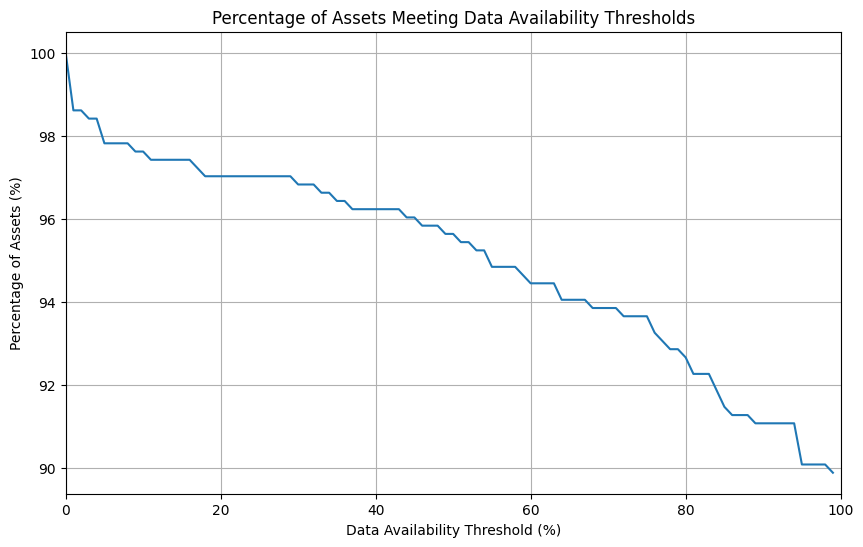

In [5]:
# Check data availability for each stock
df_returns_avail = df_returns_raw.count()  # count available returns for each column
df_returns_avail_pct = (df_returns_avail / len(df_returns_raw) * 100) # calculate percentage of available data

# Calculate how many assets meet different data availability thresholds
df_thresholds = pd.concat(
                {pct: (df_returns_avail_pct >= pct).value_counts() / len(df_returns_avail_pct) * 100 for pct in range(0, 101, 1)},
                # NOTE: this is a good place to talk about dictionary comprehensions a fun python feature
                axis=1).T

df_thresholds[True].plot(figsize=(10, 6), 
                            title='Percentage of Assets Meeting Data Availability Thresholds', 
                            xlabel='Data Availability Threshold (%)', 
                            ylabel='Percentage of Assets (%)',
                            xlim=(0, 100),
                            grid=True)

print(df_thresholds.tail(26).round(2))

We can use the above chart to callibrate a cutoff point of data availability.

In [6]:
# apply standard cleaning steps to the returns data
def clean_returns(df, threshold=0.99):
    df_cleaned = df.replace(0.0, np.nan)  # replace 0.0 with NaN
    df_cleaned = df_cleaned.dropna(axis=0, how='all')  # drop rows with all NaN values
    df_cleaned = df_cleaned.dropna(axis=1, thresh=threshold * len(df_cleaned))
    return df_cleaned.fillna(0.0)

~ excersise #2 ~

In [7]:
# TODO: Use the clean_returns function to clean the returns data. Name it df_returns
df_returns = clean_returns(df_returns_raw, threshold=0.99)

# TODO: Create a new DataFrame for stock returns and market returns. Name them df_stock_returns and df_market_returns respectively.
df_stock_returns = df_returns.drop(columns='SPX Index')  # drop the SPX Index column
df_market_returns = df_returns['SPX Index']  # keep the SPX Index column as market returns

~ --- ~

<Axes: title={'center': 'Number of Available Assets Before and After Cleaning'}, xlabel='Date', ylabel='Number of Available Asset'>

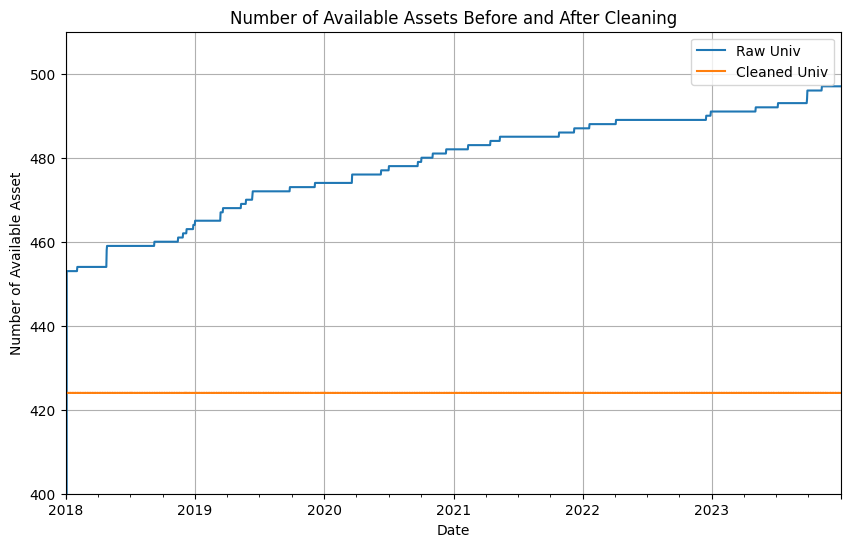

In [8]:
pd.concat([df_returns_raw.count(axis=1).rename('Raw Univ'), df_returns.count(axis=1).rename('Cleaned Univ')], axis=1)\
    .plot(figsize=(10, 6),
          title='Number of Available Assets Before and After Cleaning',
          xlabel='Date',
          ylabel='Number of Available Asset',
          grid=True,
          ylim=(400,510))

### Feature Engineering

The empirical “momentum effect” says that stocks that out-performed their peers over the last few months tend, on average, to keep doing well (and vice-versa).  
To measure that effect we first need a **252-trading-day cumulative return** for every stock, updated daily.

> **Why 252?**  
> 252 trading days ≈ 12 calendar months – a common horizon in academic momentum literature.

> **Why the 20D shift?**  
> the 20-day shift (approximately one month) helps us avoid the short-term mean reversion effect, where stocks that experience sudden large moves tend to partially reverse in the very short term.

To calculate the 252-day return, we use the following formula:

$$R_{252} = \exp\left(\sum_{t=1}^{252} \ln(1 + r_t)\right) - 1$$





~ excersise #3 ~

In [9]:
# TODO: Implement the above in code. Call it df_252d_stock_returns.
df_252d_stock_returns = df_stock_returns.add(1).apply(np.log).rolling(window=252, min_periods=40).sum().apply(np.exp).sub(1).shift(20).bfill()

~ --- ~

Next, we move onto basic data cleaning techniques.

**Winsorization** is a critical statistical technique in financial data analysis that reduces the impact of extreme values without completely removing observations. In financial datasets, extreme outliers are common due to market shocks and genuinely abnormal market events. In applications like factor modeling and portfolio construction, winsorization is often applied cross-sectionally to ensure that no single security exerts undue influence on portfolio weights or risk estimates.

**Z-score standardization** transforms raw momentum metrics into a scale-free, cross-sectionally comparable measure which allows us to properly rank and compare stocks against the universe at a specific point in time, regardless of the absolute magnitude of recent returns or market volatility conditions.

In [10]:
@pf.register_dataframe_method
def winsorize(df, percentile=0.01, axis=0):
    clip_axis = 1 if axis == 0 else 0
    lower_bound = df.quantile(percentile, axis=axis)
    upper_bound = df.quantile(1 - percentile, axis=axis)
    return df.clip(lower=lower_bound, upper=upper_bound, axis=clip_axis)

@pf.register_dataframe_method
def zstandardize(df, axis=0):
    stdz_axis = 1 if axis == 0 else 0
    mean = df.mean(axis=axis)
    std = df.std(axis=axis)
    return df.sub(mean, axis=stdz_axis).div(std, axis=stdz_axis)

~ excersise #4 ~

In [11]:
# TODO: Use the custom methods to winsorize and zstandardize the 252-day stock returns. Call it df_stock_mom_score.
df_stock_mom_score = df_252d_stock_returns.winsorize(percentile=0.01, axis=1).zstandardize(axis=1)

~ --- ~

How did we change the raw feature into something usable? i.e. What is the impact of our cleaning transformation?

       120 Day Returns  120 Day Returns Winsorized/Z-Standardized
count        637884.00                                  637884.00
mean              0.12                                      -0.00
std               0.37                                       1.00
min              -0.88                                      -2.59
25%              -0.09                                      -0.67
50%               0.06                                      -0.10
75%               0.26                                       0.54
max              11.76                                       5.00


<Axes: title={'center': 'Effect of Winsorization and Z-Standardization on 120-Day Returns'}, xlabel='Returns Type', ylabel='Returns'>

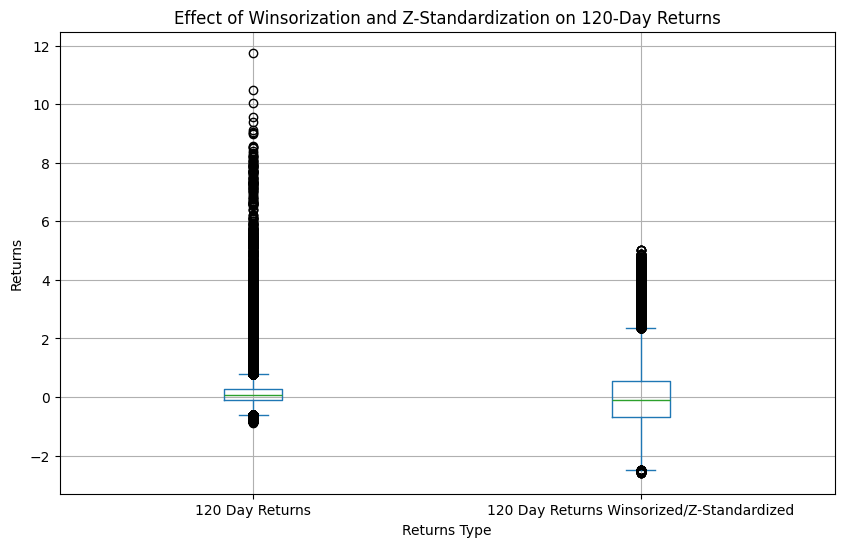

In [12]:
df_wins_stdz_effect = pd.concat([df_252d_stock_returns.stack().rename('120 Day Returns'), df_stock_mom_score.stack().rename('120 Day Returns Winsorized/Z-Standardized')], axis=1)

print(df_wins_stdz_effect.describe().round(2))

df_wins_stdz_effect.plot(kind='box', figsize=(10, 6),
                    title='Effect of Winsorization and Z-Standardization on 120-Day Returns',
                    xlabel='Returns Type',
                    ylabel='Returns',
                    grid=True)

<Axes: title={'center': 'Distribution of Momentum Score(120-Day Risk Adjusted Stock Returns Winsorized and Z-Standardized)'}, xlabel='Momentum Score', ylabel='Frequency'>

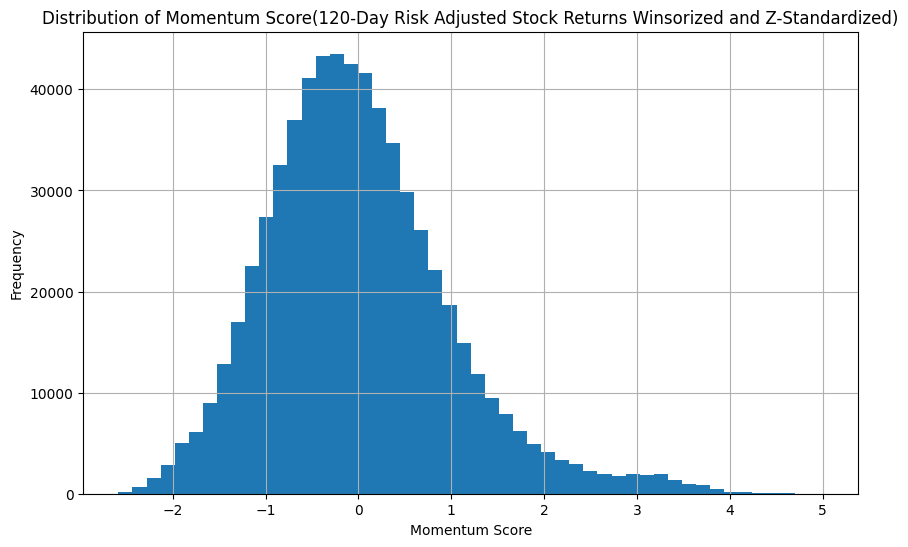

In [13]:
df_stock_mom_score.stack().plot.hist(bins=50, figsize=(10, 6),
                                                  title='Distribution of Momentum Score(120-Day Risk Adjusted Stock Returns Winsorized and Z-Standardized)',
                                                  xlabel='Momentum Score',
                                                  ylabel='Frequency',
                                                  grid=True)

##

---

## Alpha Modeling

### Signal Generation

A well-designed signal function transforms raw financial metrics into investment signals with the following characteristics (there's probably other good properties, but these are the most important in my opinion):

- **Normalization** - transforms raw scores into a consistent, bounded range (typically [-1, 1])

- **Robustness to outliers** - prevents extreme input values from creating disproportionate signals

- **Symmetry** - treats positive and negative values equivalently unless asymmetry is intentionally designed

- **Monotonicity** - preserves the rank ordering of the original scores

To show the gambit of signal functions, see the demo below

In [14]:
from helpers.signal_functions import *

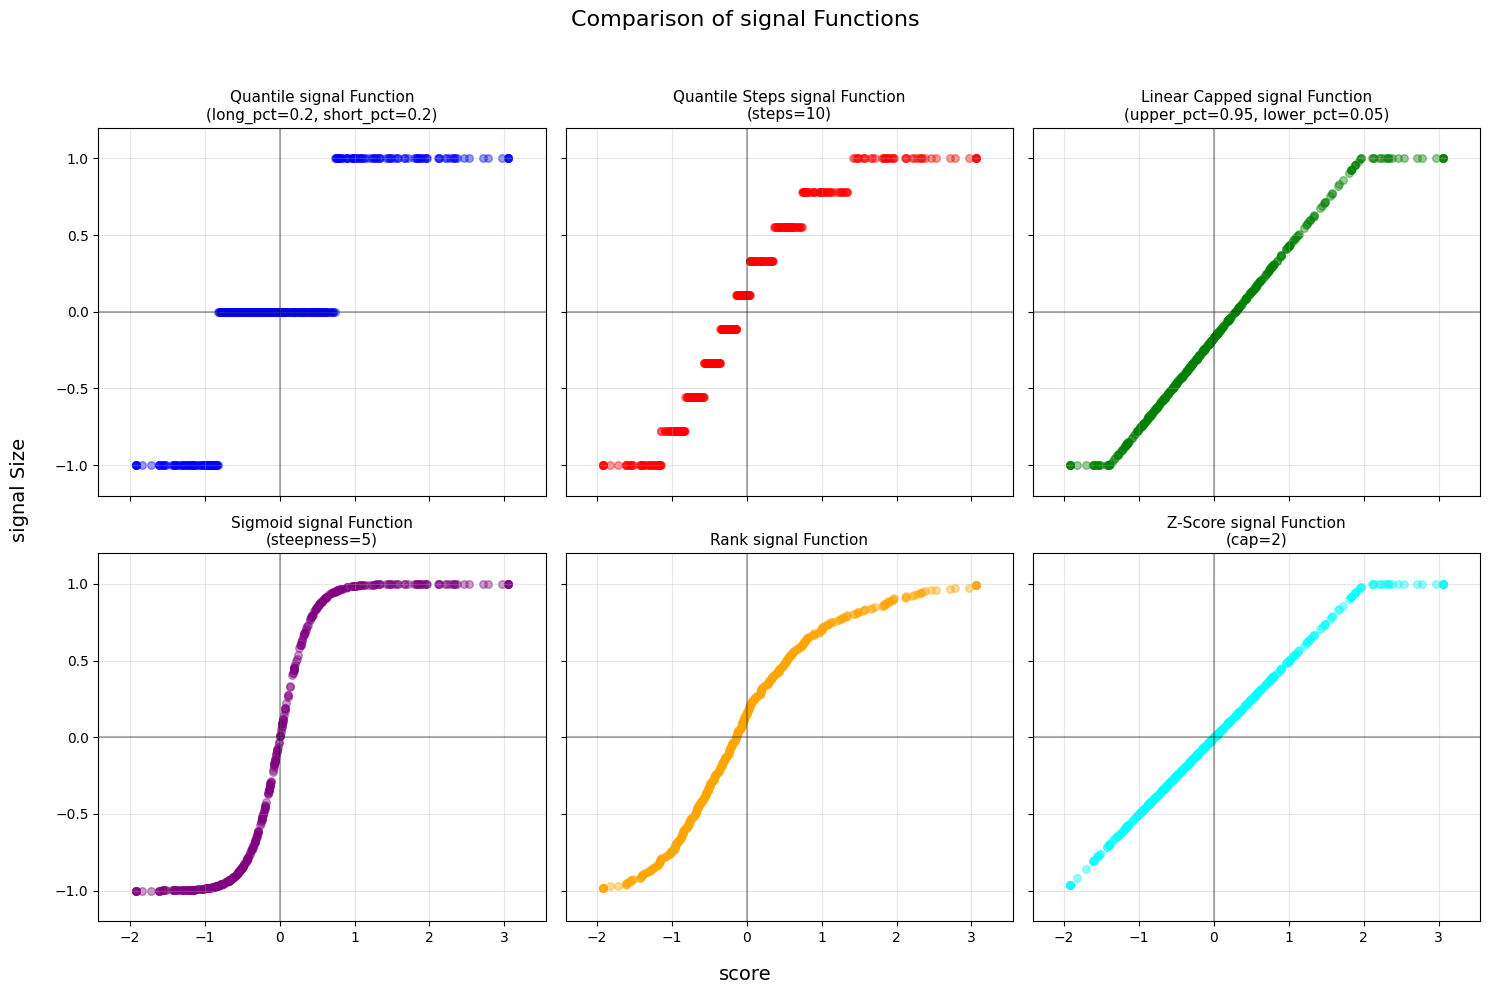

In [15]:
signal_function_demo(df_stock_mom_score)
plt.show()

For our purposes, we'll go with a simple linear capped signal.

In [16]:
df_signal = df_stock_mom_score.linear_capped_signals(lower_pct=0.05, upper_pct=0.95).shift(1)  # generate linear capped signals

Let's plot the signal against the momentum score to visualize the relationship


<Axes: title={'center': 'Signal vs. Momentum Score'}, xlabel='Momentum Score', ylabel='Signal'>

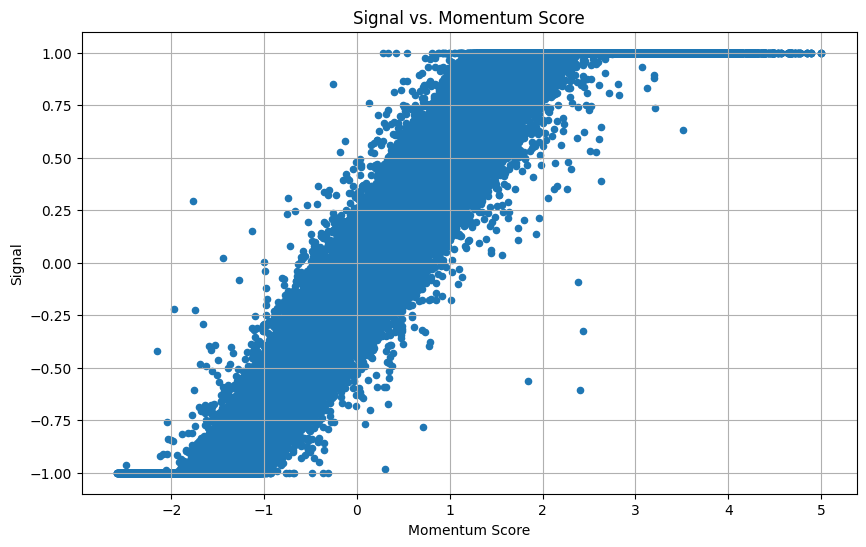

In [17]:
pd.concat([df_signal.stack().rename('Signal'), df_stock_mom_score.stack().rename('Momentum Score')], axis=1).plot(kind='scatter', x='Momentum Score', y='Signal', figsize=(10, 6),
                            title='Signal vs. Momentum Score',
                            xlabel='Momentum Score',
                            ylabel='Signal',
                            grid=True)

What about the predictive power of the signal?

>We can check the signal's predictive power by looking at the next day and next 40 day returns

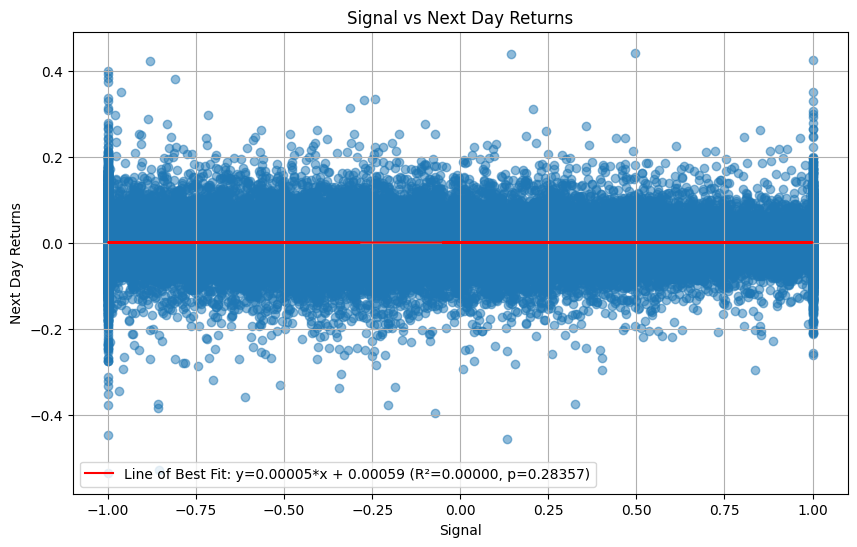

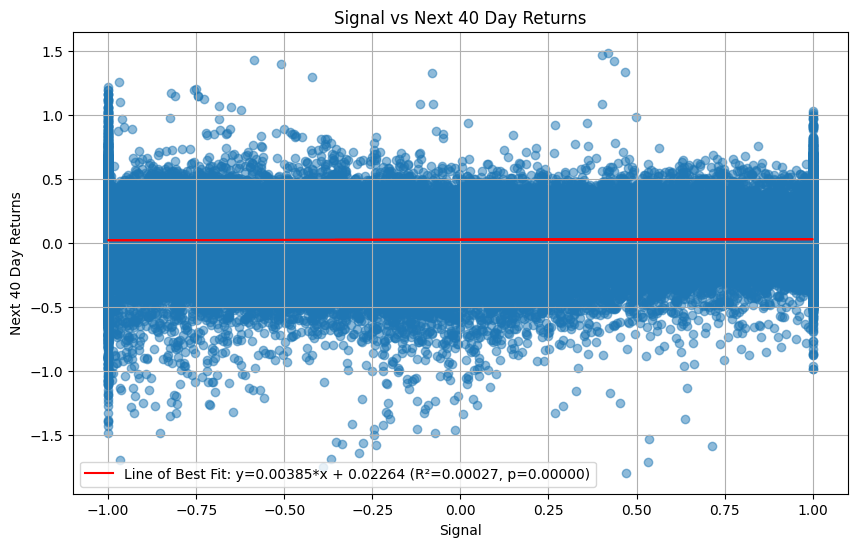

In [18]:
next_1day_return = df_stock_returns.shift(-1)  # shift returns to get next day returns
next_40day_return = df_stock_returns.rolling(40).sum().shift(-40-1)  # shift returns to get next 10 day returns

ch.plot_scatter_with_line_of_best_fit(df_signal.stack(), next_1day_return.stack(),
                                   title='Signal vs Next Day Returns',
                                   xlabel='Signal',
                                   ylabel='Next Day Returns')

ch.plot_scatter_with_line_of_best_fit(df_signal.stack(), next_40day_return.stack(),
                                   title='Signal vs Next 40 Day Returns',
                                   xlabel='Signal',
                                   ylabel='Next 40 Day Returns')

Cross sectional momentum is saying less about the next period's returns and more about the relative ranking of the stocks with their peers.
> You can see this by looking at the transition matrix of the signal vs the next 40 day returns. What you want to see is darker values on the diagonal going from the bottom left to the top right.

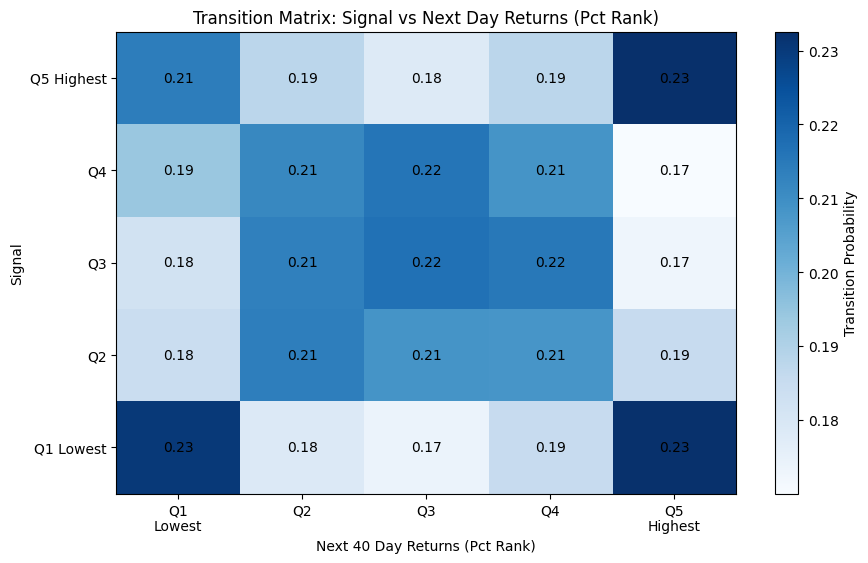

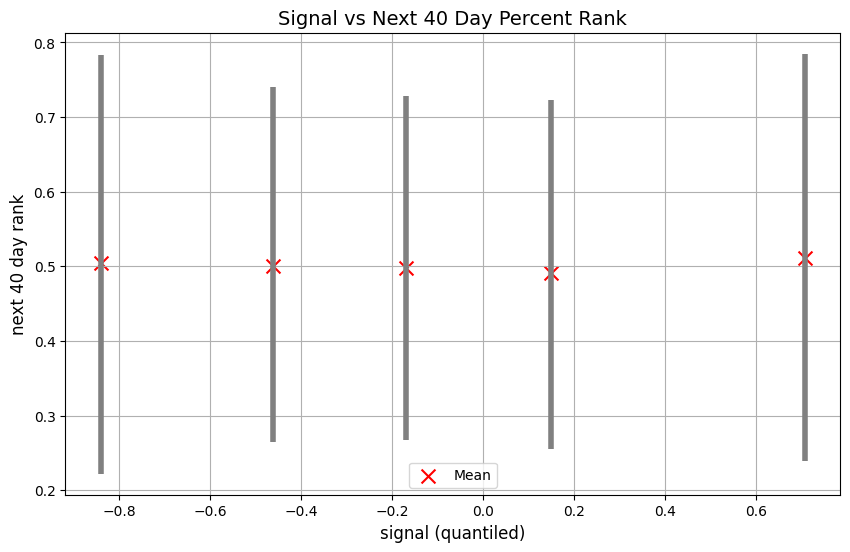

In [19]:
next_40day_pct_rank = df_stock_returns.rolling(40).sum().rank(axis=1, ascending=True, method='first', pct=True).shift(-40-1)  # shift returns to get next 10 day returns

ch.plot_transition_matrix(df_signal.stack(), next_40day_pct_rank.stack(),
                       num_of_quantiles=5,
                       normalize='index',
                       title='Transition Matrix: Signal vs Next Day Returns (Pct Rank)',
                       xlabel='Next 40 Day Returns (Pct Rank)',
                       ylabel='Signal')

ch.plot_mojo(pd.concat([df_signal.stack().rename('signal'), next_40day_pct_rank.stack().rename('next 40 day rank')], axis=1).dropna(),
             x='signal',
             y='next 40 day rank',
             q=5,
             percentiles=[25, 75], # zoom in on the 25th and 75th percentiles (or closer if needed)
             figsize=(10, 6),
             title='Signal vs Next 40 Day Percent Rank',
             show_outliers=False)

While these signals are computed cross sectionally (i.e. in a multi-channel fashion), it's important to remember that each stock gets its own signal that can be viewed overtime

~ excersise #5 ~

<Axes: title={'center': 'Sample Signals for First 10 Stocks'}, xlabel='Date', ylabel='Signal Value'>

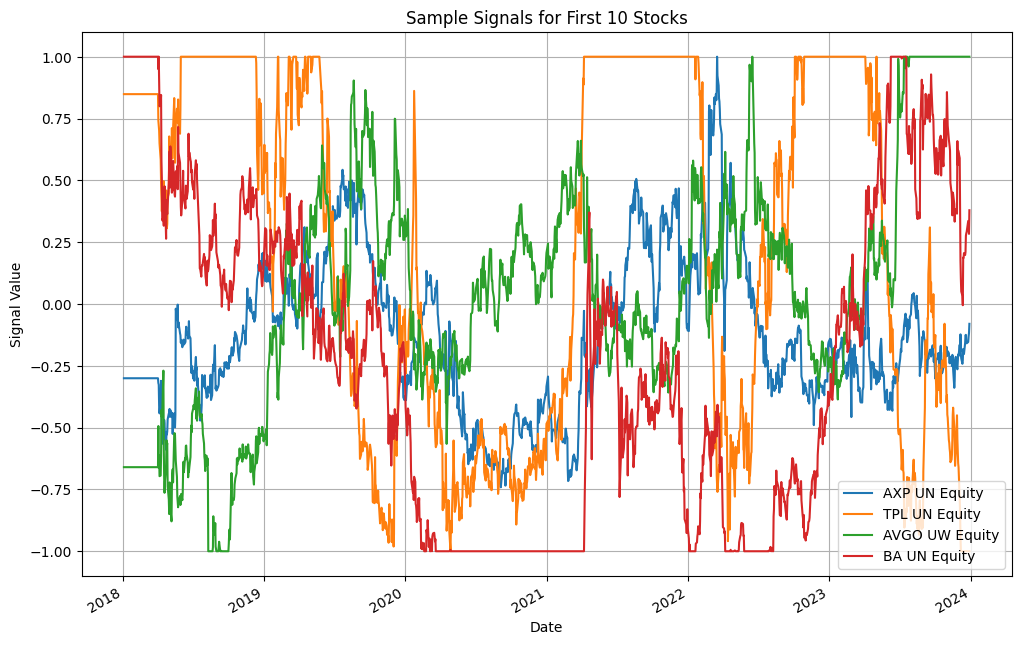

In [20]:
# TODO: Plot the first 5 stocks' signals overtime.
df_signal.iloc[:,1:5].plot(figsize=(12, 8),
                            title='Sample Signals for First 10 Stocks',
                            xlabel='Date',
                            ylabel='Signal Value',
                            grid=True)

~ --- ~

##

---

## Risk Management

### Risk Limits

When implementing portfolio risk management, we'll focus on these five fundamental components, though it's important to note that professional risk management systems often employ dozens of additional measures and constraints:

- **Volatility Target** - Adjusting overall portfolio exposure to maintain a consistent level of volatility, helping to stabilize returns across different market regimes.

- **Dollar Neutrality** - Ensuring the sum of long positions equals the sum of short positions, creating a portfolio that's insensitive to broad market movements.

- **Beta Neutrality** - Overlaying a hedging position to achieve zero market beta exposure, providing protection against directional market risk beyond simple dollar balancing.

- **Maximum Gearing** - Setting a ceiling on the total leverage used by the portfolio, limiting the amplification of both gains and losses.

- **Maximum Position Size** - Restricting the allocation to any single security to prevent concentration risk and reduce the impact of idiosyncratic events.

##

---

## Portfolio Construction

### Position Function

A position function is a mathematical transformation that converts **raw alpha signals** into actual portfolio allocations while incorporating **risk limits** and **transactions costs** (which we're ignoring in this demo).

In [21]:
from helpers.position_functions import *

We've implemented a fairly simple position function that takes our momentim signals and returns a dataframe of same shape with positions based on the configuration passed. 
> As a basic example of what we're doing, the below scatter plot shows the relationship between the signal and the position.

<Axes: title={'center': 'Position vs Signal (Portfolio Target Volatilty: 10%)'}, xlabel='Signal', ylabel='Position'>

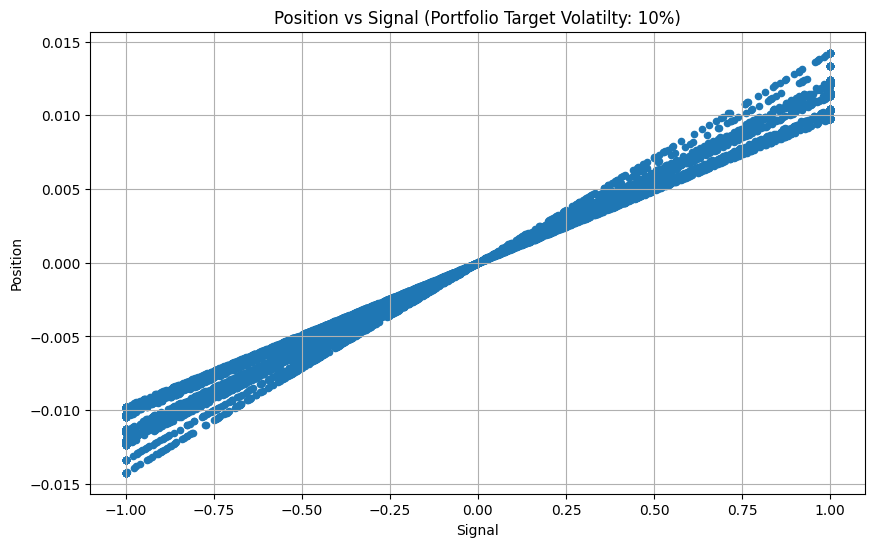

In [22]:
df_posn_func = position_function(df_signal, df_stock_returns, df_market_returns).loc['2018-06']
pd.concat([df_posn_func.stack().rename('Position'), df_signal.stack().rename('Signal')], axis=1).plot(kind='scatter', x='Signal', y='Position', figsize=(10, 6),
                            title='Position vs Signal (Portfolio Target Volatilty: 10%)',
                            xlabel='Signal',
                            ylabel='Position',
                            grid=True)

### Implement Portfolios (with different risk configurations)

Now let's implement various portfolios with different configurations to show the importance of portfolio construction decisions

~ excersise #6 ~

In [23]:
# TODO: Implement various configurations of the position functions simulating different portfolio strategies. Name the resulting DataFrame df_momentum_positions.
df_momentum_positions = pd.concat({
    'raw_pf': position_function(
        df_signal, df_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=False, beta_neutral=False, # target volatility set for 10%
        max_gearing=None, max_posn=None, window=40
    ),
    'dollar_neutral_pf': position_function(
        df_signal, df_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=False, # add dollar neutral flag
        max_gearing=None, max_posn=None, window=40
    ),
    'dollar_beta_neutral_pf': position_function(
        df_signal, df_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=True, # add beta neutral flag
        max_gearing=None, max_posn=None, window=40
    ),
    'dollar_beta_neutral_max_lev_pf': position_function(
        df_signal, df_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=True, 
        max_gearing=1.25, max_posn=0.03, window=40 # add max gearing and max position size
    )
}, axis=1, names=['portfolio', 'Security'])

~ --- ~

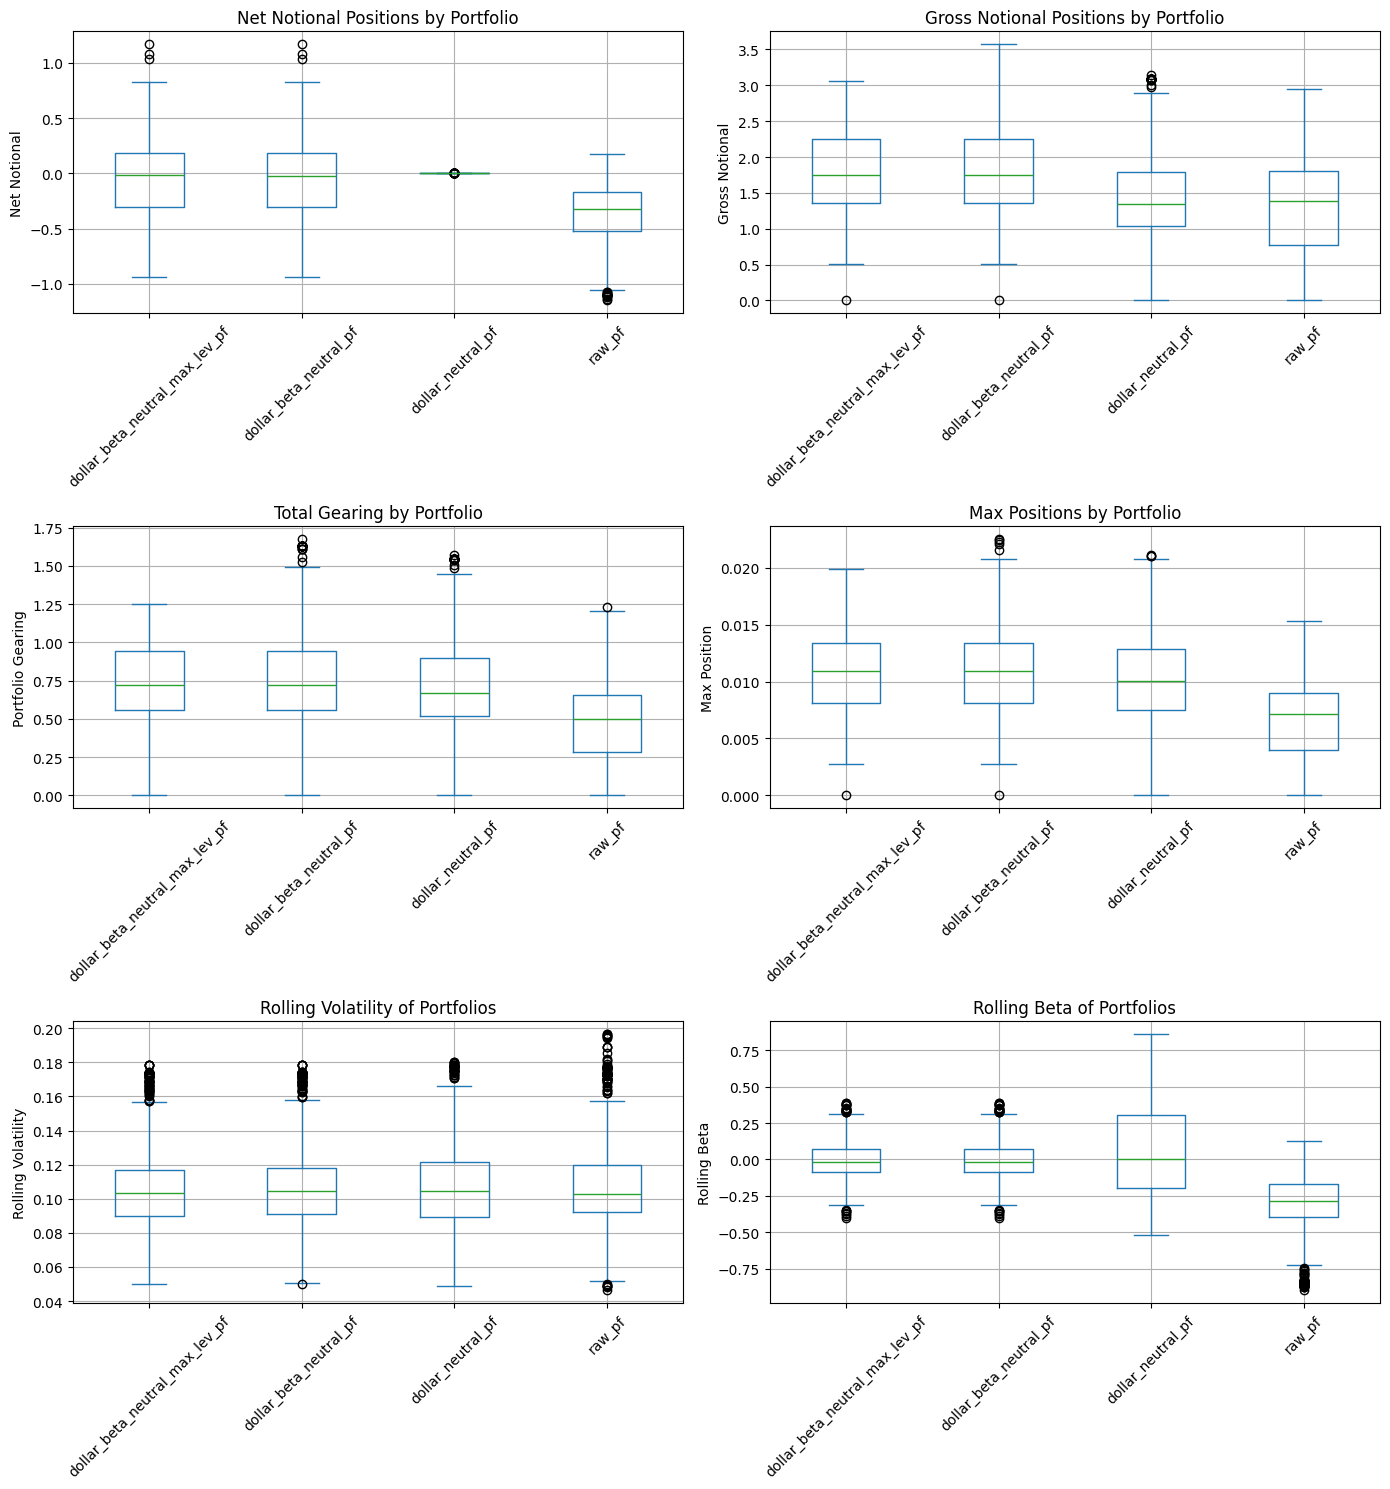

In [24]:
risk_management_demo(df_momentum_positions, df_returns, df_market_returns)
plt.show()

##

---

## Backtest

Let's put this all together and see how these implementations of the strategy has done ...

In [25]:
from helpers.performance_functions import performance_summary

In [26]:
# Compute the portfolio returns for each portfolio 
df_momentum_rets = pd.DataFrame()
for pf in df_momentum_positions.columns.get_level_values('portfolio').unique():
    df_momentum_rets[pf] = df_momentum_positions[pf].get_portfolio_returns(df_returns)

# add the market returns adjusted for volatility for comparison
df_mkt_vol_adj_rets = df_market_returns.mul(0.1 / (df_market_returns.std() * (np.sqrt(252))))

df_portfolios_rets = pd.concat([df_momentum_rets, df_mkt_vol_adj_rets], axis=1).loc['2018-03':]

... by plotting at a time series of their performance overtime ...

~ excersise #7 ~

<Axes: title={'center': 'Portfolio Returns Comparison'}, xlabel='Date', ylabel='Returns'>

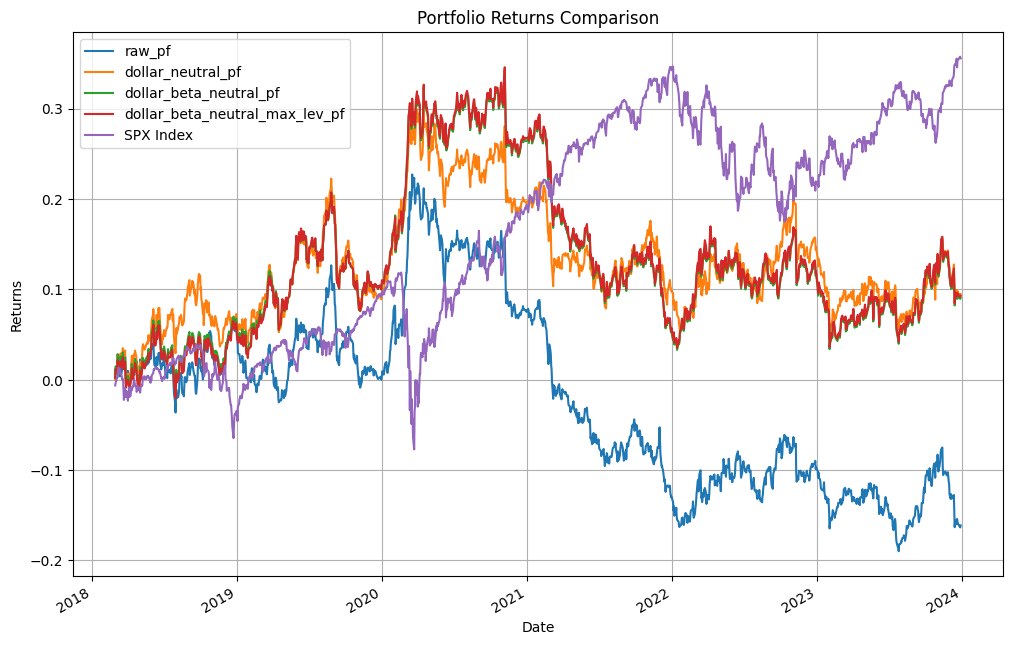

In [27]:
# TODO: Plot the portfolio returns for each portfolio
df_portfolios_rets.add(1).cumprod().sub(1)\
    .plot(figsize=(12, 8),
          title='Portfolio Returns Comparison',
          xlabel='Date',
          ylabel='Returns',
          grid=True)

~ --- ~

... and looking at some key performance statistics.

~ excersise #7 ~

In [28]:
# TODO: Calculate and display the performance summary for each portfolio. Use the performance_summary function from the performance_functions module.
performance_summary(df_portfolios_rets, 252, risk_free_rate=0.0, benchmark_r=df_market_returns)

,raw_pf,dollar_neutral_pf,dollar_beta_neutral_pf,dollar_beta_neutral_max_lev_pf,SPX Index
Annualized Return,-0.029731,0.01564,0.014945,0.015319,0.053577
Annualized Volatility,0.109218,0.108585,0.107612,0.107058,0.10011
Skewness,-0.621206,-0.92739,-0.819703,-0.801003,-0.482711
Kurtosis,7.900257,8.035326,7.910637,7.855096,15.911825
Is Normal,False,False,False,False,False
Sharpe Ratio,-0.272217,0.144034,0.138874,0.143088,0.535181
Beta to Benchmark,-0.251149,-0.030048,-0.029559,-0.02933,0.48516
Correlation to Benchmark,-0.47449,-0.0571,-0.056679,-0.05653,1.0
Monthly Historic VaR (95%),0.011231,0.011404,0.011498,0.011434,0.009299
Monthly Historic CVaR (95%),0.015608,0.016415,0.016238,0.016123,0.015244


~ --- ~

##

---

## Conclusion

As a reminder, the lesson that I hope you take away from this are:

- **Quantitative investing is really a chain of “small” problems**

- **Data is the lifeblood**

- **Alpha is rewarded, orthogonal risk**

- **Risk management is about keeping risk-taking intentional**

- **Bias vigilance**